## 01 Getting & Knowing your Data - Ex 2

In [ ]:
# Step 1. Import the necessary libraries
import pandas as pd
import numpy as np

In [76]:
# Step 2-4
url = "https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv"
chipo = pd.read_csv(url, sep="\t")
chipo.head(10)

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98
5,3,1,Chicken Bowl,"[Fresh Tomato Salsa (Mild), [Rice, Cheese, Sou...",$10.98
6,3,1,Side of Chips,NaN,$1.69
7,4,1,Steak Burrito,"[Tomatillo Red Chili Salsa, [Fajita Vegetables...",$11.75
8,4,1,Steak Soft Tacos,"[Tomatillo Green Chili Salsa, [Pinto Beans, Ch...",$9.25
9,5,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Pinto...",$9.25


In [ ]:
# Step 5. What is the number of observations in the dataset?
len(chipo), chipo.shape[0]

(4622, 4622)

In [ ]:
# Step 6. What is the number of columns in the dataset?
chipo.shape[1]

5

In [ ]:
# Step 7. Print the name of all the columns.
chipo.columns

Index(['order_id', 'quantity', 'item_name', 'choice_description',
       'item_price'],
      dtype='str')

In [ ]:
# Step 8. How is the dataset indexed?
chipo.index

RangeIndex(start=0, stop=4622, step=1)

In [ ]:
# Step 9. Which was the most-ordered item?

#chipo.groupby('item_name')["quantity"].sum().sort_values(ascending=False).index[0]
orders_count = chipo.groupby('item_name')["quantity"].sum()
orders_count.idxmax()

'Chicken Bowl'

In [56]:
# Step 10. For the most-ordered item, how many items were ordered?
orders_count.max()

np.int64(761)

In [61]:
# Step 11. What was the most ordered item in the choice_description column?
chipo.groupby('choice_description')["quantity"].sum().sort_values(ascending=False).head(1)

choice_description
[Diet Coke]    159
Name: quantity, dtype: int64

In [ ]:
# Step 12. How many items were orderd in total?
chipo["quantity"].sum()

np.int64(4972)

In [ ]:
# Step 13. Turn the item price into a float
print(chipo["item_price"].dtype) # str
chipo["item_price"] = chipo["item_price"].apply(lambda x: float(x[1:]))
print(chipo["item_price"].dtype)
chipo.head(3)

str
float64


,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,2.39
1,1,1,Izze,[Clementine],3.39
2,1,1,Nantucket Nectar,[Apple],3.39


In [135]:
# Step 14. How much was the revenue for the period in the dataset?
chipo["item_price"].sum()

np.float64(34500.16)

In [93]:
# Step 15. How many orders were made in the period?
chipo["order_id"].value_counts().count()

np.int64(1834)

In [136]:
# Step 16. What is the average revenue amount per order?
chipo["item_price"].sum() / chipo["order_id"].value_counts().count()


np.float64(18.811428571428575)

In [101]:
# Step 17. How many different items are sold?
chipo["item_name"].value_counts().count()

np.int64(50)

## 02 Filtering and Sorting Data - Ex 1

In [190]:
chipo = pd.read_csv(url, sep="\t")
chipo["item_price"] = chipo["item_price"].apply(lambda x: float(x[1:]))
chipo.head()
chipo["unit_price"] = chipo["item_price"] / chipo["quantity"] 

In [188]:
# Step 4. How many products cost more than $10.00?
chipo[chipo["unit_price"] > 10][["item_name", "choice_description"]].value_counts().count()

np.int64(707)

In [201]:
# Step 5. What is the price of each item?
#prices = chipo.groupby(["item_name", "choice_description"])["unit_price"].mean()

item_prices = chipo[["item_name", "unit_price", "choice_description"]].drop_duplicates()
item_prices.head()

,item_name,unit_price,choice_description
0,Chips and Fresh Tomato Salsa,2.39,NaN
1,Izze,3.39,[Clementine]
2,Nantucket Nectar,3.39,[Apple]
3,Chips and Tomatillo-Green Chili Salsa,2.39,NaN
4,Chicken Bowl,8.49,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans..."


In [149]:
# Step 6. Sort by the name of the item
chipo.sort_values(by="item_name").head(10)

,order_id,quantity,item_name,choice_description,item_price,price
3389,1360,2,6 Pack Soft Drink,[Diet Coke],12.98,6.49
341,148,1,6 Pack Soft Drink,[Diet Coke],6.49,6.49
1849,749,1,6 Pack Soft Drink,[Coke],6.49,6.49
1860,754,1,6 Pack Soft Drink,[Diet Coke],6.49,6.49
2713,1076,1,6 Pack Soft Drink,[Coke],6.49,6.49
3422,1373,1,6 Pack Soft Drink,[Coke],6.49,6.49
553,230,1,6 Pack Soft Drink,[Diet Coke],6.49,6.49
1916,774,1,6 Pack Soft Drink,[Diet Coke],6.49,6.49
1922,776,1,6 Pack Soft Drink,[Coke],6.49,6.49
1937,784,1,6 Pack Soft Drink,[Diet Coke],6.49,6.49


In [202]:
# Step 7. What was the quantity of the most expensive item ordered?
chipo[chipo["item_price"] == max(chipo["item_price"])][["quantity", "item_name"]]

,quantity,item_name
3598,15,Chips and Fresh Tomato Salsa


In [174]:
# Step 8. How many times was a Veggie Salad Bowl ordered?
chipo[chipo["item_name"] == "Veggie Salad Bowl"]["order_id"].count()

np.int64(18)

In [178]:
# Step 9. How many times did someone order more than one Canned Soda?
chipo[(chipo["item_name"] == "Canned Soda") & (chipo["quantity"] > 1)]["order_id"].count()

np.int64(20)

## 03 Grouping - Occupation

In [252]:
url_occupation = "https://raw.githubusercontent.com/justmarkham/DAT8/master/data/u.user"

users = pd.read_csv(url_occupation,sep="|")
users.head()

,user_id,age,gender,occupation,zip_code
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213


In [253]:
# Step 4. Discover what is the mean age per occupation
users.groupby("occupation")["age"].mean()

occupation
administrator    38.746835
artist           31.392857
doctor           43.571429
educator         42.010526
engineer         36.388060
entertainment    29.222222
executive        38.718750
healthcare       41.562500
homemaker        32.571429
lawyer           36.750000
librarian        40.000000
marketing        37.615385
none             26.555556
other            34.523810
programmer       33.121212
retired          63.071429
salesman         35.666667
scientist        35.548387
student          22.081633
technician       33.148148
writer           36.311111
Name: age, dtype: float64

In [254]:
# Step 5. Discover the Male ratio per occupation and sort it from the most to the least
# users[users["gender" ] == "F"].groupby("occupation")["occupation"].count() / users.groupby(["occupation"])["occupation"].count()
users["gender"] = users["gender"] == "F"
users.groupby("occupation")["gender"].mean().sort_values(ascending=False)

occupation
homemaker        0.857143
healthcare       0.687500
librarian        0.568627
artist           0.464286
administrator    0.455696
none             0.444444
writer           0.422222
marketing        0.384615
other            0.342857
student          0.306122
educator         0.273684
salesman         0.250000
lawyer           0.166667
entertainment    0.111111
scientist        0.096774
executive        0.093750
programmer       0.090909
retired          0.071429
technician       0.037037
engineer         0.029851
doctor           0.000000
Name: gender, dtype: float64

In [248]:
# Step 6. For each occupation, calculate the minimum and maximum ages
users.groupby("occupation")["age"].max(), users.groupby("occupation")["age"].min()

(occupation
 administrator    70
 artist           48
 doctor           64
 educator         63
 engineer         70
 entertainment    50
 executive        69
 healthcare       62
 homemaker        50
 lawyer           53
 librarian        69
 marketing        55
 none             55
 other            64
 programmer       63
 retired          73
 salesman         66
 scientist        55
 student          42
 technician       55
 writer           60
 Name: age, dtype: int64,
 occupation
 administrator    21
 artist           19
 doctor           28
 educator         23
 engineer         22
 entertainment    15
 executive        22
 healthcare       22
 homemaker        20
 lawyer           21
 librarian        23
 marketing        24
 none             11
 other            13
 programmer       20
 retired          51
 salesman         18
 scientist        23
 student           7
 technician       21
 writer           18
 Name: age, dtype: int64)

In [249]:
# Step 7. For each combination of occupation and gender, calculate the mean age
users.groupby(["occupation", "gender"])["age"].mean()

occupation     gender
administrator  False     37.162791
               True      40.638889
artist         False     32.333333
               True      30.307692
doctor         False     43.571429
educator       False     43.101449
               True      39.115385
engineer       False     36.600000
               True      29.500000
entertainment  False     29.000000
               True      31.000000
executive      False     38.172414
               True      44.000000
healthcare     False     45.400000
               True      39.818182
homemaker      False     23.000000
               True      34.166667
lawyer         False     36.200000
               True      39.500000
librarian      False     40.000000
               True      40.000000
marketing      False     37.875000
               True      37.200000
none           False     18.600000
               True      36.500000
other          False     34.028986
               True      35.472222
programmer     False     33.21666

In [ ]:
# Step 8. For each occupation present the percentage of women and men
percentage = users.groupby("occupation")["gender"].mean().to_frame().reset_index()
percentage["male"] = 1 - percentage["gender"]
percentage

# users.groupby('occupation')['gender'].value_counts()

,occupation,gender,male
0,administrator,0.455696,0.544304
1,artist,0.464286,0.535714
2,doctor,0.000000,1.000000
3,educator,0.273684,0.726316
4,engineer,0.029851,0.970149
5,entertainment,0.111111,0.888889
6,executive,0.093750,0.906250
7,healthcare,0.687500,0.312500
8,homemaker,0.857143,0.142857
9,lawyer,0.166667,0.833333


## 04 Apply - student_alcohol_consumption

In [308]:
url_apply = "https://raw.githubusercontent.com/guipsamora/pandas_exercises/master/04_Apply/Students_Alcohol_Consumption/student-mat.csv"

df = pd.read_csv(url_apply)
df = df.loc[:,"school":"guardian"]
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother
4,GP,F,16,U,GT3,T,3,3,other,other,home,father


In [309]:
# Step 5. Create a lambda function that will capitalize strings.
capitalizer_function = lambda x: x.capitalize()

In [310]:
# Step 6. Capitalize both Mjob and Fjob
df["Mjob"] = df["Mjob"].apply(capitalizer_function)
df["Fjob"] = df["Fjob"].apply(capitalizer_function)
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian
0,GP,F,18,U,GT3,A,4,4,At_home,Teacher,course,mother
1,GP,F,17,U,GT3,T,1,1,At_home,Other,course,father
2,GP,F,15,U,LE3,T,1,1,At_home,Other,other,mother
3,GP,F,15,U,GT3,T,4,2,Health,Services,home,mother
4,GP,F,16,U,GT3,T,3,3,Other,Other,home,father
...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,Services,Services,course,other
391,MS,M,17,U,LE3,T,3,1,Services,Services,course,mother
392,MS,M,21,R,GT3,T,1,1,Other,Other,course,other
393,MS,M,18,R,LE3,T,3,2,Services,Other,course,mother


In [311]:
# Step 7. Print the last elements of the data set.
df.iloc[-5:,:]

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian
390,MS,M,20,U,LE3,A,2,2,Services,Services,course,other
391,MS,M,17,U,LE3,T,3,1,Services,Services,course,mother
392,MS,M,21,R,GT3,T,1,1,Other,Other,course,other
393,MS,M,18,R,LE3,T,3,2,Services,Other,course,mother
394,MS,M,19,U,LE3,T,1,1,Other,At_home,course,father


In [312]:
# Step 9. Create a function called majority that returns a boolean value to a new column called legal_drinker (Consider majority as older than 17 years old)
def majority(age):
    return age >= 17

df["legar_drinker"] = df["age"].apply(majority)
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,legar_drinker
0,GP,F,18,U,GT3,A,4,4,At_home,Teacher,course,mother,True
1,GP,F,17,U,GT3,T,1,1,At_home,Other,course,father,True
2,GP,F,15,U,LE3,T,1,1,At_home,Other,other,mother,False
3,GP,F,15,U,GT3,T,4,2,Health,Services,home,mother,False
4,GP,F,16,U,GT3,T,3,3,Other,Other,home,father,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,Services,Services,course,other,True
391,MS,M,17,U,LE3,T,3,1,Services,Services,course,mother,True
392,MS,M,21,R,GT3,T,1,1,Other,Other,course,other,True
393,MS,M,18,R,LE3,T,3,2,Services,Other,course,mother,True


In [313]:
# Step 10. Multiply every number of the dataset by 10.
df[["age", "Medu", "Fedu"]] *= 10
df

def multiply(x):
    if type(x) is int or type(x) is float:
        return x*10
    return x

df.apply(multiply)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,legar_drinker
0,GP,F,180,U,GT3,A,40,40,At_home,Teacher,course,mother,True
1,GP,F,170,U,GT3,T,10,10,At_home,Other,course,father,True
2,GP,F,150,U,LE3,T,10,10,At_home,Other,other,mother,False
3,GP,F,150,U,GT3,T,40,20,Health,Services,home,mother,False
4,GP,F,160,U,GT3,T,30,30,Other,Other,home,father,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,200,U,LE3,A,20,20,Services,Services,course,other,True
391,MS,M,170,U,LE3,T,30,10,Services,Services,course,mother,True
392,MS,M,210,R,GT3,T,10,10,Other,Other,course,other,True
393,MS,M,180,R,LE3,T,30,20,Services,Other,course,mother,True


## 05 Merge - Housing Market

In [474]:
raw_data_1 = {
        'subject_id': ['1', '2', '3', '4', '5'],
        'first_name': ['Alex', 'Amy', 'Allen', 'Alice', 'Ayoung'], 
        'last_name': ['Anderson', 'Ackerman', 'Ali', 'Aoni', 'Atiches']}

raw_data_2 = {
        'subject_id': ['4', '5', '6', '7', '8'],
        'first_name': ['Billy', 'Brian', 'Bran', 'Bryce', 'Betty'], 
        'last_name': ['Bonder', 'Black', 'Balwner', 'Brice', 'Btisan']}

raw_data_3 = {
        'subject_id': ['1', '2', '3', '4', '5', '7', '8', '9', '10', '11'],
        'test_id': [51, 15, 15, 61, 16, 14, 15, 1, 61, 16]}

data1 = pd.DataFrame(raw_data_1)
data2 = pd.DataFrame(raw_data_2)
data3 = pd.DataFrame(raw_data_3)

In [483]:
# Step 3. Assign each to a variable called data1, data2, data3
data_all = pd.concat([data1, data2])
data_all

,subject_id,first_name,last_name
0,1,Alex,Anderson
1,2,Amy,Ackerman
2,3,Allen,Ali
3,4,Alice,Aoni
4,5,Ayoung,Atiches
0,4,Billy,Bonder
1,5,Brian,Black
2,6,Bran,Balwner
3,7,Bryce,Brice
4,8,Betty,Btisan


In [485]:
# Step 5. Join the two dataframes along columns and assing to all_data_col
data_all_col = pd.concat([data1, data2], axis=1)
data_all_col


,subject_id,first_name,last_name,subject_id,first_name,last_name
0,1,Alex,Anderson,4,Billy,Bonder
1,2,Amy,Ackerman,5,Brian,Black
2,3,Allen,Ali,6,Bran,Balwner
3,4,Alice,Aoni,7,Bryce,Brice
4,5,Ayoung,Atiches,8,Betty,Btisan


In [486]:
# Step 7. Merge all_data and data3 along the subject_id value
pd.merge(data_all, data3, how="inner", on="subject_id")

,subject_id,first_name,last_name,test_id
0,1,Alex,Anderson,51
1,2,Amy,Ackerman,15
2,3,Allen,Ali,15
3,4,Alice,Aoni,61
4,5,Ayoung,Atiches,16
5,4,Billy,Bonder,61
6,5,Brian,Black,16
7,7,Bryce,Brice,14
8,8,Betty,Btisan,15


In [487]:
# Step 8. Merge only the data that has the same 'subject_id' on both data1 and data2
pd.merge(data1, data2, how="inner", on="subject_id")

,subject_id,first_name_x,last_name_x,first_name_y,last_name_y
0,4,Alice,Aoni,Billy,Bonder
1,5,Ayoung,Atiches,Brian,Black


In [489]:
# Step 9. Merge all values in data1 and data2, with matching records from both sides where available.
pd.merge(data1,data2, how="outer", on="subject_id")

,subject_id,first_name_x,last_name_x,first_name_y,last_name_y
0,1,Alex,Anderson,NaN,NaN
1,2,Amy,Ackerman,NaN,NaN
2,3,Allen,Ali,NaN,NaN
3,4,Alice,Aoni,Billy,Bonder
4,5,Ayoung,Atiches,Brian,Black
5,6,NaN,NaN,Bran,Balwner
6,7,NaN,NaN,Bryce,Brice
7,8,NaN,NaN,Betty,Btisan


## 06 Stats - US_Baby_names

In [348]:
url_baby = "https://raw.githubusercontent.com/guipsamora/pandas_exercises/master/06_Stats/US_Baby_Names/US_Baby_Names_right.csv"

baby_names = pd.read_csv(url_baby)
baby_names.head(10)

,Unnamed: 0,Id,Name,Year,Gender,State,Count
0,11349,11350,Emma,2004,F,AK,62
1,11350,11351,Madison,2004,F,AK,48
2,11351,11352,Hannah,2004,F,AK,46
3,11352,11353,Grace,2004,F,AK,44
4,11353,11354,Emily,2004,F,AK,41
5,11354,11355,Abigail,2004,F,AK,37
6,11355,11356,Olivia,2004,F,AK,33
7,11356,11357,Isabella,2004,F,AK,30
8,11357,11358,Alyssa,2004,F,AK,29
9,11358,11359,Sophia,2004,F,AK,28


In [354]:
#Step 5. Delete the column 'Unnamed: 0' and 'Id'
baby_names = baby_names.drop(["Unnamed: 0",'Id'], axis=1)

In [355]:
# Step 6. What year has the highest number of baby names in the dataset?
baby_names.groupby('Year')["Name"].count().sort_values(ascending=False)

Year
2008    94970
2009    94609
2007    94332
2014    94148
2010    93307
2012    93024
2013    92743
2011    92545
2006    91803
2005    88494
2004    86420
Name: Name, dtype: int64

In [356]:
# Step 7. Is there more male or female names in the dataset?
baby_names[baby_names["Gender"] == "M"]["Count"].sum() # 19041199
baby_names[baby_names["Gender"] == "F"]["Count"].sum() # 16380293

np.int64(16380293)

In [357]:
baby_names

,Name,Year,Gender,State,Count
0,Emma,2004,F,AK,62
1,Madison,2004,F,AK,48
2,Hannah,2004,F,AK,46
3,Grace,2004,F,AK,44
4,Emily,2004,F,AK,41
...,...,...,...,...,...
1016390,Seth,2014,M,WY,5
1016391,Spencer,2014,M,WY,5
1016392,Tyce,2014,M,WY,5
1016393,Victor,2014,M,WY,5


In [360]:
# Step 8. Group the dataset by name and assign to names
names = baby_names.groupby('Name')["Count"].sum()
names

Name
Aaban        12
Aadan        23
Aadarsh       5
Aaden      3426
Aadhav        6
           ... 
Zyra         42
Zyrah        11
Zyren         6
Zyria        59
Zyriah       58
Name: Count, Length: 17632, dtype: int64

In [362]:
# Step 9. How many different names exist in the dataset?
names.count()

np.int64(17632)

In [366]:
# Step 10. What is the name with most occurrences?
names.idxmax()

'Jacob'

In [380]:
# Step 11. How many different names have the least occurrences?
len(names[names == min(names)])

2578

In [381]:
# Step 12. What is the median name occurrence?
names.median()

np.float64(49.0)

In [382]:
# Step 13. What is the standard deviation of names?
names.std()

np.float64(11006.06946789057)

In [386]:
# Step 14. Get a summary with the mean, min, max, std and quartiles.
names.describe()

count     17632.000000
mean       2008.932169
std       11006.069468
min           5.000000
25%          11.000000
50%          49.000000
75%         337.000000
max      242874.000000
Name: Count, dtype: float64

## 07 Visualization - Chipotle

In [387]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

Matplotlib is building the font cache; this may take a moment.


In [392]:
chipo = pd.read_csv(url, sep="\t")
chipo.head(10)

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98
5,3,1,Chicken Bowl,"[Fresh Tomato Salsa (Mild), [Rice, Cheese, Sou...",$10.98
6,3,1,Side of Chips,NaN,$1.69
7,4,1,Steak Burrito,"[Tomatillo Red Chili Salsa, [Fajita Vegetables...",$11.75
8,4,1,Steak Soft Tacos,"[Tomatillo Green Chili Salsa, [Pinto Beans, Ch...",$9.25
9,5,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Pinto...",$9.25


Text(0, 0.5, 'Item name')

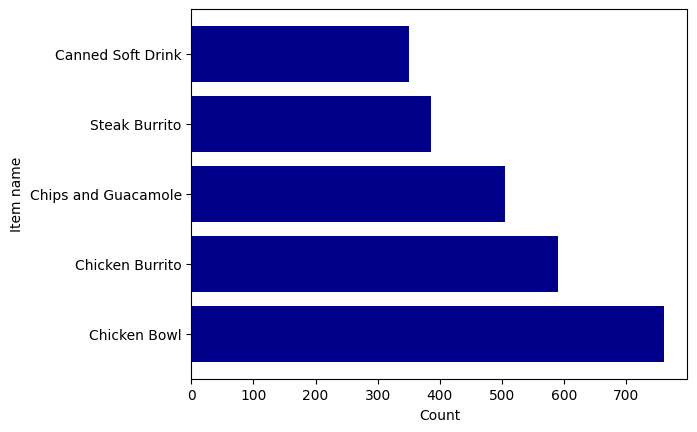

In [430]:
# Step 5. Create a histogram of the top 5 items bought  (I think it should be bar plot)
top_items = chipo.groupby("item_name")["quantity"].sum().sort_values(ascending=False).iloc[:5]
plt.barh(top_items.index, top_items.values, color="darkblue")
plt.xlabel("Count")
plt.ylabel("Item name")

Text(0, 0.5, 'quantity')

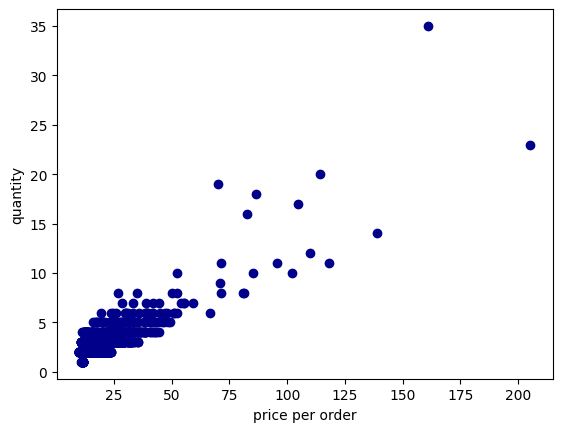

In [ ]:
# Step 6. Create a scatterplot with the number of items orderered per order price
chipo["item_price"] = chipo["item_price"].apply(lambda x: float(x[1:]))
price_per_order = chipo.groupby("order_id")[["item_price", "quantity"]].sum().reset_index()
plt.scatter(price_per_order["item_price"], price_per_order["quantity"], color="darkblue")
plt.xlabel("price per order")
plt.ylabel("quantity")

Text(0.5, 0, 'Average quantity')

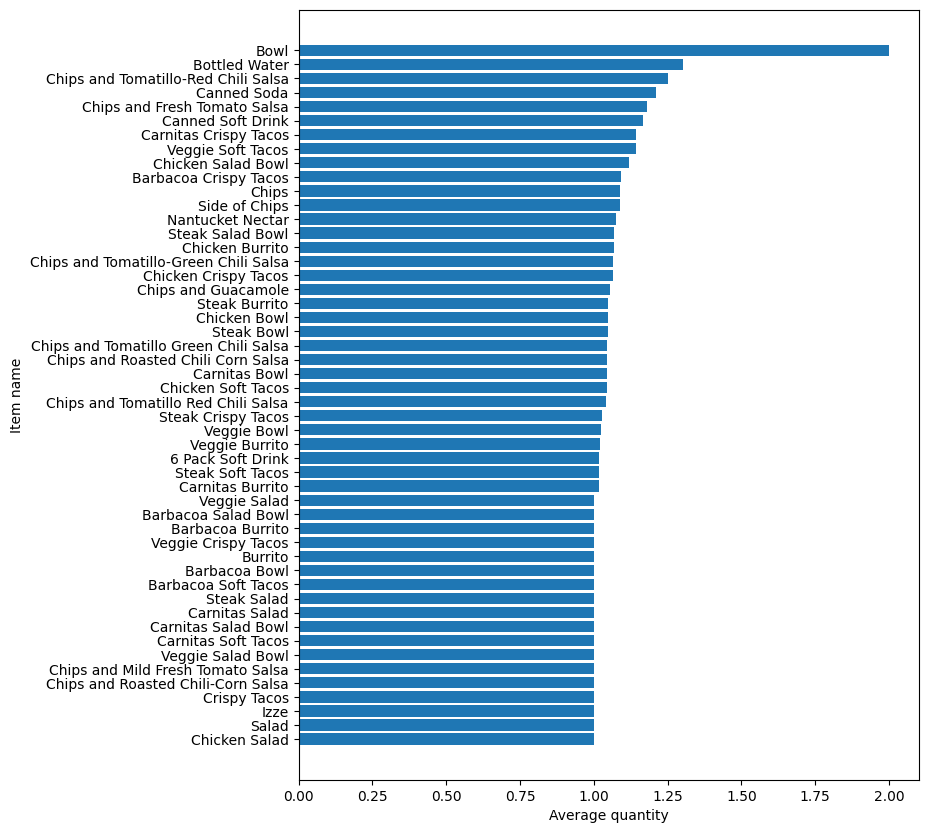

In [468]:
# Step 7. BONUS: Create a question and a graph to answer your own question.
# which items are most often bought in larger quantities?
data = chipo.groupby("item_name")["quantity"].mean().sort_values()
plt.figure(figsize=(8,10))
plt.barh(data.index, data.values)
plt.ylabel("Item name")
plt.xlabel("Average quantity")
